In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

We follow the discussion of M and Q in https://epubs.siam.org/doi/epdf/10.1137/16M1104664

The triad system can be written as 

$
\begin{equation}
\begin{split}
d x_1 &= [ L_2 x_3 - L_3 x_2 -d_1 x_1 + B_1 x_2 x_3 + F_1 ] dt +\sigma_1 dW_1 \\
d x_2 &= [ L_3 x_1 - L_1 x_3 -d_2 x_2 + B_2 x_3 x_1 + F_2 ] dt +\sigma_2 dW_2 \\
d x_3 &= [ L_1 x_2 - L_2 x_1 -d_3 x_3 + B_3 x_1 x_2 + F_3 ] dt +\sigma_3 dW_3 \\
\end{split}
\label{eq:triad_system} 
\end{equation}
$

We solve it using Euler-Mayurama and explore the different regimes that arise from this system

# Code for Triad system

In [2]:
# Linear operator
def lin_op(d1,d2,d3,L1,L2,L3):
    return np.array([[-d1,-L3,L2],[L3,-d2,-L1],[-L2,L1,-d3]])

# Nonlinear operator
def nonlinear_op(B1,B2,B3,x):
    return np.array([B1*x[1]*x[2], B2*x[2]*x[0], B3*x[0]*x[1]])

# Variance of the Wiener process
def Sigma(s_1,s_2,s_3):
    return np.array([s_1, s_2, s_3])

# Forcing
def forcing(F1,F2,F3):
    return np.array([F1, F2, F3])

In [3]:
def triad_system(x_0,F,L,S,dt,N):
    
    ### Inputs
    # x_0: initial condition. E.g. np.array(0.01,0.2,0.3)
    # L: linear operator. 
    # B: nonlinear operator
    # S: variance of the Wiener process
    # dt: integration time stepping
    # N: number of integration steps
    
    # Array for results
    x = np.zeros([N+1,len(x_0)])
    
    # Set initial condition
    x[0] = x_0
    
    # forward integration via Euler-Mayurama scheme
    for t in range(N):
        # Deterministic part
        det_part = (F + np.matmul(L,x[t]) + nonlinear_op(B1,B2,B3,x[t]))*dt
        # Stochastic part
        stoch_part = S*np.random.normal(0, 1, len(x_0))*np.sqrt(dt)
        x[t+1] = x[t] + det_part + stoch_part

    return x

## Regime c ---> Nonlinear regime with dual energy cascade

In [24]:
L1, L2, L3 = np.array([0.09, 0.06, -0.03]);
d1, d2, d3 =  np.array([1, 2, 2]);
B1, B2, B3 = np.array([2, -1, -1]);
F1, F2, F3 = np.array([0, -1, 1]);
s_1,s_2,s_3 = np.sqrt(np.array([10, 0.01, 0.01]))
x_0 = np.array([-0.01,  0.02 ,  0.03 ])

In [26]:
F = forcing(F1,F2,F3)
L = lin_op(d1,d2,d3,L1,L2,L3)
S = Sigma(s_1,s_2,s_3)
dt = 0.001 # 
transient = 1000
N = 50000000 + transient

In [27]:
system_regime_c = triad_system(x_0,F,L,S,dt,N)[transient:]

# Gaussian case with same mean and variance
gauss_case = []
mean = np.mean(system_regime_c,axis=0)
std = np.std(system_regime_c,axis=0)
for i in range(N): 
    gauss_case.append(np.random.normal(mean, std))
gauss_case = np.array(gauss_case)

In [28]:
np.save('./results/gauss_case.npy',gauss_case)

In [29]:
np.save('./results/x_trajectory_CONTINUOUS.npy',system_regime_c)

(1e-05, 4.13708400431761)

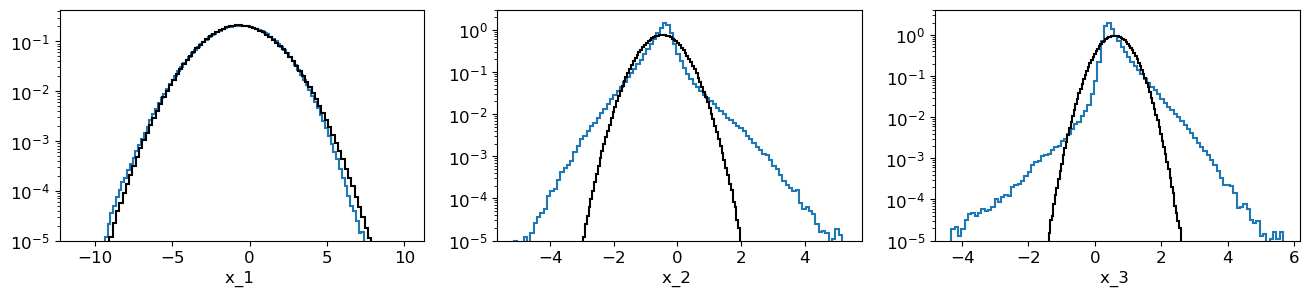

In [31]:
fig = plt.figure(figsize=(16,3))

fontsize_ticks = 12

ax = fig.add_subplot(131)  
n, bins, patches = plt.hist(system_regime_c[:,0], bins= 100,  histtype = 'step',
                                linewidth = 1.5,rwidth=1,log = True, label= 'original',density=True)

n, bins, patches = plt.hist(gauss_case[:,0], bins= 100,  histtype = 'step',
                                linewidth = 1.5, color = 'k',rwidth=1,log = True, label= 'original',density=True)

plt.xlabel('x_1 ',fontsize = 12)
plt.xticks(fontsize = fontsize_ticks)
plt.yticks(fontsize = fontsize_ticks)
plt.ylim(10**(-5))

ax = fig.add_subplot(132)  

n, bins, patches = plt.hist(system_regime_c[:,1], bins= 100,  histtype = 'step',
                                linewidth = 1.5,rwidth=1,log = True, label= 'original',density=True)

n, bins, patches = plt.hist(gauss_case[:,1], bins= 100,  histtype = 'step',
                                linewidth = 1.5, color = 'k',rwidth=1,log = True, label= 'original',density=True)

plt.xlabel('x_2 ',fontsize = 12)
plt.xticks(fontsize = fontsize_ticks)
plt.yticks(fontsize = fontsize_ticks)
plt.ylim(10**(-5))

ax = fig.add_subplot(133)  

n, bins, patches = plt.hist(system_regime_c[:,2], bins= 100,  histtype = 'step',
                                linewidth = 1.5,rwidth=1,log = True, label= 'original',density=True)

n, bins, patches = plt.hist(gauss_case[:,2], bins= 100,  histtype = 'step',
                                linewidth = 1.5, color = 'k',rwidth=1,log = True, label= 'original',density=True)

plt.xlabel('x_3 ',fontsize = 12)
plt.xticks(fontsize = fontsize_ticks)
plt.yticks(fontsize = fontsize_ticks)
plt.ylim(10**(-5))

#fig.savefig('./figures/continuous.pdf',bbox_inches='tight') # bbox_inches='tight' 